# 评估 Notebook：AI 初始化 vs 零初始化 MIMO-FxLMS 收敛对比（evaluate_anc.ipynb）

本 Notebook 在一个 **全新（未见）** 的仿真房间中，比较两种初始化下的 MIMO-FxLMS 收敛速度：
- Baseline: 传统零初始化（或全零滤波器）
- Proposed: 使用预训练的 `MIMO_Conditioned_ANCNet` 进行一次前向预测，得到 `W_AI_init` 作为初始化，然后运行 FxLMS

主要步骤：
1. 使用与数据集构建一致的采样分布（但不同随机种子）生成一个新房间并构建 RIR（确保在训练分布内但未复现训练样本）。
2. 生成同一段白噪声激励，提取参考麦克风前 50 ms 信号并按训练时的 FeatureProcessor 计算 `gcc_phat` 和 `psd_features`。
3. 使用训练时的全局 SVD 基（从 HDF5 读取 `S_components` / `S_mean` 与 `W_components` / `W_mean`）对 `S_full_test` 做投影，得到 `x_s`（32-d）。
4. 加载 `best_mimo_anc_net.pth`，前向获得 `c_pred`，重构 `W_AI_init`（shape [sec,ref,L]）。
5. 在同一条噪声 / 时间轴上分别运行： (a) 零初始化 FxLMS，(b) AI 初始化 FxLMS；记录残差波形 `e(t)`。
6. 计算滑动窗口 MSE -> dB（短时均方）并绘图比较收敛曲线，同时绘制房间布局。

**依赖**：`pyroomacoustics`, `numpy`, `torch`, `matplotlib`, `h5py`（若缺少请先在环境中安装）。

注意：该 Notebook 严格沿用了数据集脚本 `build_cfxlms_qc_dataset.py` 中的 Feature/几何采样与 SVD 约定，保证与训练时的特征维度完全一致。

In [1]:
# 环境与路径准备
import sys
from pathlib import Path
import importlib.util
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch

# 确保项目根在 sys.path，以能导入本仓库内的包（py_anc 等）
ROOT = Path.cwd()
if (ROOT / 'python_impl').exists():
    sys.path.insert(0, str(ROOT / 'python_impl'))
else:
    # 尝试上一级（若 Notebook 在 python_impl 子目录打开时）
    sys.path.insert(0, str(ROOT))

print('工作目录:', ROOT)
print('Python 环境 torch:', torch.__version__)

工作目录: z:\anc\distributed_anc_sim_py\python_impl\notebooks
Python 环境 torch: 2.4.0


In [2]:
# 自动寻找项目根并设置 sys.path 与工作目录（避免相对路径找不到脚本）
from pathlib import Path
import sys
import os

def find_repo_root(marker='python_impl/python_scripts/build_cfxlms_qc_dataset.py'):
    p = Path.cwd()
    for d in [p] + list(p.parents):
        if (d / marker).exists():
            return d
    raise FileNotFoundError(f'未在当前目录及父目录中找到 {marker}')

ROOT = find_repo_root()
print('检测到项目根:', ROOT)
# 将项目根加入 sys.path 以便相对导入；并切换当前工作目录以使相对路径有效
sys.path.insert(0, str(ROOT / 'python_impl'))
os.chdir(str(ROOT))
print('已切换工作目录到:', Path.cwd())

检测到项目根: z:\anc\distributed_anc_sim_py
已切换工作目录到: z:\anc\distributed_anc_sim_py


In [3]:
# 载入 dataset builder 中的配置与采样器（以保证与训练时一致的分布与特征计算器）
import importlib.util, types
builder_path = Path('python_impl') / 'python_scripts' / 'build_cfxlms_qc_dataset.py'
if not builder_path.exists():
    raise FileNotFoundError(f'无法找到构建脚本: {builder_path}，请确认在项目根下运行本 Notebook')
spec = importlib.util.spec_from_file_location('build_cfx', str(builder_path))
build_mod = importlib.util.module_from_spec(spec)
import sys
# 在执行模块前把 module 注册到 sys.modules，避免 dataclass 在执行期找不到模块而报错
sys.modules[spec.name] = build_mod
spec.loader.exec_module(build_mod)

# 现在我们可以使用 DatasetBuildConfig, AcousticScenarioSampler, FeatureProcessor 等类
cfg = build_mod.DatasetBuildConfig()
print('数据集配置载入，fs=', cfg.fs, 'filter_len=', cfg.filter_len, 'gcc_len=', cfg.gcc_truncated_len)

数据集配置载入，fs= 4000 filter_len= 512 gcc_len= 129


In [4]:
# 采样并构建一个新的（未见）测试房间——使用不同的随机种子以避免与训练集重复
from numpy.random import default_rng
seed_new = 20260330  # 可改为任意不同于训练的种子以保证未见性
rng = default_rng(seed_new)
sampler = build_mod.AcousticScenarioSampler(cfg, rng)
sampled = sampler.sample()  # 可能抛出 QCError，如果抛出可换 seed 重试
mgr = sampler.build_manager(sampled)
mgr.build(verbose=False)
print('采样完成。房间大小:', sampled['room_size'], '声速:', sampled['sound_speed'])
print('参考麦克风位置:', sampled['ref_positions'])
print('次级扬声器位置:', sampled['sec_positions'])
print('误差麦克风位置:', sampled['err_positions'])

采样完成。房间大小: [3.37458875 5.86357014 5.01975871] 声速: 342.0795342485719
参考麦克风位置: [[1.87475748 1.9563618  3.50871465]
 [1.27043273 1.7990991  3.49431476]
 [1.75336115 1.35871584 3.50033606]]
次级扬声器位置: [[2.0306137  2.14178225 3.50871465]
 [1.04859828 1.8509593  3.49431476]
 [1.83064255 1.05413236 3.50033606]]
误差麦克风位置: [[2.17942426 2.31882056 3.50871465]
 [0.79138087 1.91109129 3.49431476]
 [1.90074627 0.77783776 3.50033606]]


In [ ]:
# 使用与数据集一致的带限白噪声作为激励，并生成参考/期望信号
from py_anc.utils import wn_gen

duration_s = 2.0  # 仿真时长（s），可调整，但下面的特征只取前 50 ms

In [6]:
# 生成噪声、计算 reference (x) 与 desired (d)
noise_rng = np.random.default_rng(seed_new + 1)
noise, t = wn_gen(fs=cfg.fs, duration=duration_s, f_low=cfg.f_low, f_high=cfg.f_high, rng=noise_rng)
time_axis = t[:, 0].astype(float)
source_signal = noise  # wn_gen 已返回 (n,1) 列向量
# 按 RIRManager API 生成 d 和 x（已在 mgr 中注册了设备）
d = mgr.calculate_desired_signal(source_signal, len(time_axis))
x = mgr.calculate_reference_signal(source_signal, len(time_axis))
# 归一化列（与数据集处理一致）
def _normalize_columns(x_arr: np.ndarray) -> np.ndarray:
    denom = np.max(np.abs(x_arr), axis=0, keepdims=True)
    denom = np.where(denom < np.finfo(float).eps, 1.0, denom)
    return x_arr / denom
x = _normalize_columns(x)
print('信号长度:', len(time_axis), '参考通道数:', x.shape[1], '误差通道数:', d.shape[1])

信号长度: 40000 参考通道数: 3 误差通道数: 3


In [7]:
# 提取前 50 ms 的参考麦克风波形（与数据集一致的窗口长度）
ref_samples = int(cfg.ref_window_samples)
X_ref_test = x[:ref_samples, : cfg.num_nodes].T.astype(np.float32)  # shape: (3, ref_samples)
print('X_ref_test shape:', X_ref_test.shape)

# 构建 S_full_test: 次级通路完整矩阵 [sec, err, rir_len]，并按 cfg.rir_store_len 截断/补零
rir_len = int(cfg.rir_store_len)
n_nodes = int(cfg.num_nodes)
S_full_test = np.zeros((n_nodes, n_nodes, rir_len), dtype=np.float32)
for i, sec_id in enumerate(sampler.sec_ids):
    for j, err_id in enumerate(sampler.err_ids):
        r = np.asarray(mgr.get_secondary_rir(int(sec_id), int(err_id)), dtype=float)
        keep = min(rir_len, r.size)
        S_full_test[i, j, :keep] = r[:keep].astype(np.float32)

# primary/ P_full_test（primary->err）
P_full_test = np.zeros((1, n_nodes, rir_len), dtype=np.float32)
pri_id = int(sampler.source_id)
for j, err_id in enumerate(sampler.err_ids):
    r = np.asarray(mgr.get_primary_rir(pri_id, int(err_id)), dtype=float)
    keep = min(rir_len, r.size)
    P_full_test[0, j, :keep] = r[:keep].astype(np.float32)

# 计算理论参考 W_opt（通过局部解或使用构建器的快速返回，若想要严格按最优解需要求解 Wiener 方程；这里我们不用于仿真，仅保存作参考）
# 训练脚本里 W_opt 是由 ANCDatasetBuilder.evaluate_anc 计算并写入 HDF5；我们这里不重复推导，只保留占位
W_opt_test = None  # 如需，可以通过运行 ANCDatasetBuilder.evaluate_anc 获得（开销较大）
print('S_full_test shape:', S_full_test.shape, 'P_full_test shape:', P_full_test.shape)

X_ref_test shape: (3, 200)
S_full_test shape: (3, 3, 512) P_full_test shape: (1, 3, 512)


In [8]:
# 从已有 HDF5 数据集中加载全局 SVD 基底（用于将 S_full_test 投影为 32-d 条件向量）
h5_path = Path('python_impl') / 'python_scripts' / 'cfxlms_qc_dataset_cross_500_seeded.h5'
if not h5_path.exists():
    raise FileNotFoundError(f'需要 HDF5 数据集以读取全局 SVD 基底: {h5_path}，请先生成或提供该文件')
with h5py.File(str(h5_path), 'r') as hf:
    s_comp = np.asarray(hf['processed/global_svd/S_components'], dtype=np.float32)
    s_mean = np.asarray(hf['processed/global_svd/S_mean'], dtype=np.float32)
    w_comp = np.asarray(hf['processed/global_svd/W_components'], dtype=np.float32)
    w_mean = np.asarray(hf['processed/global_svd/W_mean'], dtype=np.float32)
print('Loaded S_components shape:', s_comp.shape, 'W_components shape:', w_comp.shape)

Loaded S_components shape: (32, 4608) W_components shape: (32, 4608)


In [9]:
# 使用与数据集一致的 FeatureProcessor 计算 GCC-PHAT 与 PSD（保证维度一致）
feat_proc = build_mod.FeatureProcessor(cfg)
gcc = feat_proc.compute_gcc_phat(X_ref_test)  # shape (3, 129)
psd = feat_proc.compute_psd_features(X_ref_test[0])  # shape (129,)
# 合并为训练期望的 x_p 形状 (1, 4, 129)
x_p = np.vstack([gcc, psd.reshape(1, -1)]).astype(np.float32)  # (4,129)
x_p_t = torch.from_numpy(x_p).unsqueeze(0)  # (1,4,129)

# 将 S_full_test 扁平化并投影到 S_components 得到物理条件向量 (1,32)
s_flat = S_full_test.reshape(-1).astype(np.float32)  # shape (s_feature_dim,)
s_centered = (s_flat - s_mean).astype(np.float32)
# s_comp shape: (n_components, s_feature_dim) -> proj: (s_feature_dim,) @ (s_feature_dim, n_comp) -> (n_comp,)
s_coeff = s_centered @ s_comp.T  # (32,)
x_s_t = torch.from_numpy(s_coeff.astype(np.float32)).unsqueeze(0)  # (1,32)

print('x_p_t shape:', x_p_t.shape, 'x_s_t shape:', x_s_t.shape)

x_p_t shape: torch.Size([1, 4, 129]) x_s_t shape: torch.Size([1, 32])


## 载入预训练模型并做一次前向推理，得到 AI 初始化的控制滤波器 W_AI_init
模型代码与训练时一致（为避免导入训练脚本带来的副作用，这里直接复刻模型定义）。

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class MIMO_Conditioned_ANCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=5, stride=2, padding=2)
        self.ln1 = nn.LayerNorm((16, 65))
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2)
        self.ln2 = nn.LayerNorm((32, 33))
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.ln3 = nn.LayerNorm((64, 17))
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.s_fc1 = nn.Linear(32, 64)
        self.s_ln1 = nn.LayerNorm(64)
        self.s_fc2 = nn.Linear(64, 64)
        self.s_ln2 = nn.LayerNorm(64)
        self.f_fc1 = nn.Linear(128, 128)
        self.f_ln1 = nn.LayerNorm(128)
        self.f_drop = nn.Dropout(0.2)
        self.f_fc2 = nn.Linear(128, 64)
        self.f_fc3 = nn.Linear(64, 32)
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                try:
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                except Exception:
                    nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x_p, x_s):
        z = self.conv1(x_p)
        z = F.gelu(self.ln1(z))
        z = self.conv2(z)
        z = F.gelu(self.ln2(z))
        z = self.conv3(z)
        z = F.gelu(self.ln3(z))
        z = self.pool(z)
        z_p = z.view(z.size(0), -1)
        z_s = F.gelu(self.s_ln1(self.s_fc1(x_s)))
        z_s = F.gelu(self.s_ln2(self.s_fc2(z_s)))
        zf = torch.cat([z_p, z_s], dim=1)
        zf = F.gelu(self.f_ln1(self.f_fc1(zf)))
        zf = self.f_drop(zf)
        zf = F.gelu(self.f_fc2(zf))
        c_pred = self.f_fc3(zf)
        return c_pred

# 加载权重（查找常见路径）
possible_paths = [Path('best_mimo_anc_net.pth'), Path('python_impl') / 'notebooks' / 'best_mimo_anc_net.pth']
model_path = None
for p in possible_paths:
    if p.exists():
        model_path = p
        break
if model_path is None:
    raise FileNotFoundError('找不到模型文件 best_mimo_anc_net.pth，请先在训练目录保存该文件或把路径放到工作目录。')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MIMO_Conditioned_ANCNet().to(device)
state = torch.load(str(model_path), map_location=device)
model.load_state_dict(state)
model.eval()
print('已加载模型', model_path, 'device:', device)

已加载模型 best_mimo_anc_net.pth device: cuda


C:\Windows\Temp\ipykernel_16564\1930901992.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(model_path), map_location=device)


In [11]:
# 前向预测并物理解码得到 W_AI_init（shape: sec x ref x L）
with torch.no_grad():
    xp = x_p_t.to(device=device, dtype=torch.float32)
    xs = x_s_t.to(device=device, dtype=torch.float32)
    c_pred = model(xp, xs)  # (1,32)
    # 将全局 W_components 与 W_mean 转为 torch tensor（保证在 CPU 上）
    Wc = torch.from_numpy(w_comp.astype(np.float32)).to(device=device)  # (32, 4608)
    Wm = torch.from_numpy(w_mean.astype(np.float32)).to(device=device)  # (4608,)
    W_pred_flat = torch.matmul(c_pred, Wc) + Wm  # (1, 4608)
    W_pred_flat_np = W_pred_flat.cpu().numpy().reshape(-1)
    W_AI_init = W_pred_flat_np.reshape(cfg.num_nodes, cfg.num_nodes, cfg.filter_len)  # (sec,ref,L)

print('W_AI_init shape:', W_AI_init.shape)

W_AI_init shape: (3, 3, 512)


## 仿真对比：实现支持初始 W 的 CFxLMS 并运行 Baseline/AI 两次仿真
接下来我们调用仓库内的 `py_anc.algorithms.cfxlms.cfxlms`（作为 baseline），并实现一个带初始权重的 `cfxlms_with_init` 供 AI 初始化使用。

In [13]:
from py_anc.algorithms import cfxlms as cfxlms_fn

# 复制仓库中辅助函数（用于将 W_full(sec,ref,L) 转为 CFxLMS 使用的形状 [L,ref,sec]）
def _build_weight_tensor_from_w_full(w_full: np.ndarray, filter_len: int, n_ref: int, n_sec: int) -> np.ndarray:
    w = np.zeros((filter_len, n_ref, n_sec), dtype=float)
    arr = np.asarray(w_full, dtype=float)
    if arr.ndim != 3:
        raise ValueError(f'w_full 期望三维 [sec,ref,L]，实际 {arr.shape}')
    keep_sec = min(n_sec, arr.shape[0])
    keep_ref = min(n_ref, arr.shape[1])
    keep_len = min(filter_len, arr.shape[2])
    for k in range(keep_sec):
        w[:keep_len, :keep_ref, k] = arr[k, :keep_ref, :keep_len].T
    return w

# 可复用的 cfxlms_with_init（复制自 py_anc.algorithms.cfxlms 并添加可选 w_init 参数）
def cfxlms_with_init(time, rir_manager, L, mu, reference_signal, desired_signal, w_init=None, normalized_update=False, norm_epsilon=1.0e-8, verbose=False):
    # 参数与 py_anc.algorithms.cfxlms 一致，返回同样的结构{'err_hist','filter_coeffs'}
    x = np.asarray(reference_signal, dtype=float)
    d = np.asarray(desired_signal, dtype=float)
    key_sec_spks = list(rir_manager.secondary_speakers.keys())
    key_err_mics = list(rir_manager.error_microphones.keys())
    num_ref_mics = len(rir_manager.reference_microphones)
    num_sec_spks = len(key_sec_spks)
    num_err_mics = len(key_err_mics)
    n_samples = len(time)

    # 缓存次级路径
    s_paths = [[None for _ in range(num_err_mics)] for _ in range(num_sec_spks)]
    s_lens = np.zeros((num_sec_spks, num_err_mics), dtype=np.int32)
    max_ls_hat = 0
    for k, sec_id in enumerate(key_sec_spks):
        for m, err_id in enumerate(key_err_mics):
            s = np.asarray(rir_manager.get_secondary_rir(sec_id, err_id), dtype=float)
            s_paths[k][m] = s
            s_lens[k, m] = int(s.size)
            if s.size > max_ls_hat:
                max_ls_hat = int(s.size)

    # 初始化 w：若提供 w_init（sec,ref,L），则转换；否则零初始化
    if w_init is None:
        w = np.zeros((L, num_ref_mics, num_sec_spks), dtype=float)
    else:
        w = _build_weight_tensor_from_w_full(w_init, L, num_ref_mics, num_sec_spks)

    x_taps = np.zeros((max(L, max_ls_hat), num_ref_mics), dtype=float)
    xf_taps = np.zeros((L, num_ref_mics, num_sec_spks, num_err_mics), dtype=float)
    e = np.zeros((n_samples, num_err_mics), dtype=float)
    y_taps = []
    for k in range(num_sec_spks):
        sec_len = int(np.max(s_lens[k]))
        y_taps.append(np.zeros(sec_len, dtype=float))

    if verbose:
        print('开始集中式FxLMS仿真（支持初始 w）...')

    for n in range(n_samples):
        x_taps[1:, :] = x_taps[:-1, :]
        x_taps[0, :] = x[n, :]

        for k in range(num_sec_spks):
            y = np.sum(w[:, :, k] * x_taps[:L, :])
            y_taps[k][1:] = y_taps[k][:-1]
            y_taps[k][0] = y

        for m in range(num_err_mics):
            yf = 0.0
            for k in range(num_sec_spks):
                s = s_paths[k][m]
                ls = int(s_lens[k, m])
                yf += float(np.dot(s, y_taps[k][:ls]))
            e[n, m] = d[n, m] + yf

        xf_taps[1:, :, :, :] = xf_taps[:-1, :, :, :]
        for k in range(num_sec_spks):
            for m in range(num_err_mics):
                s = s_paths[k][m]
                ls_hat = int(s_lens[k, m])
                xf_taps[0, :, k, m] = s @ x_taps[:ls_hat, :]

        for k in range(num_sec_spks):
            grad_k = np.zeros((L, num_ref_mics), dtype=float)
            for m in range(num_err_mics):
                phi = xf_taps[:, :, k, m]
                if normalized_update:
                    denom = float(np.sum(phi * phi)) + norm_epsilon
                    grad_k += (phi * e[n, m]) / denom
                else:
                    grad_k += phi * e[n, m]
            w[:, :, k] = w[:, :, k] - mu * grad_k

    filter_coeffs = {sec_id: w[:, :, k].copy() for k, sec_id in enumerate(key_sec_spks)}
    return {'err_hist': e, 'filter_coeffs': filter_coeffs}

# 选取相同的 mu 与参数以保证公平比较
mu = float(cfg.mu_candidates[0] if len(cfg.mu_candidates) else 1.0e-4)
L = int(cfg.filter_len)
normalized_update = bool(cfg.anc_normalized_update)

# 运行 baseline（零初始化）
params = {
    'time': time_axis,
    'rir_manager': mgr,
    'L': L,
    'mu': mu,
    'reference_signal': x,
    'desired_signal': d,
    'verbose': False,
    'normalized_update': normalized_update,
    'norm_epsilon': float(cfg.anc_norm_epsilon),
}
res_baseline = cfxlms_fn(params)
e_baseline = np.asarray(res_baseline['err_hist'], dtype=float)
print('Baseline 仿真完成，残差形状:', e_baseline.shape)

# 运行 AI 初始化（使用 W_AI_init）
w_init_arr = np.asarray(W_AI_init, dtype=float)  # shape: (sec,ref,L)
res_ai = cfxlms_with_init(time_axis, mgr, L, mu, x, d, w_init=w_init_arr, normalized_update=normalized_update, norm_epsilon=float(cfg.anc_norm_epsilon), verbose=False)
e_ai = np.asarray(res_ai['err_hist'], dtype=float)
print('AI-init 仿真完成，残差形状:', e_ai.shape)

Baseline 仿真完成，残差形状: (40000, 3)
AI-init 仿真完成，残差形状: (40000, 3)


window_samples= 500 window_s= 0.125


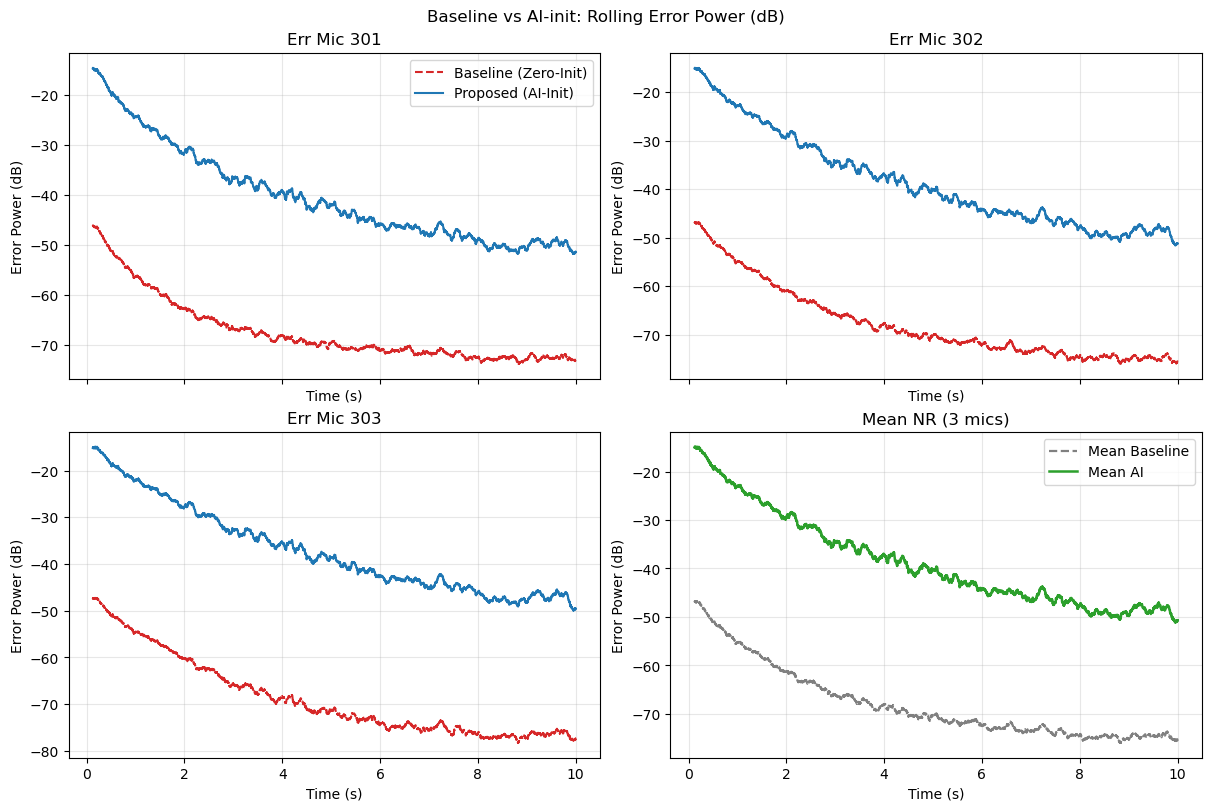

In [14]:
# 计算滑动窗口的短时能量并转换为 dB（rolling MSE -> dB）
def rolling_mse_db(sig: np.ndarray, fs: int, window_samples: int = 500):
    # sig: 1D 时间序列
    n = sig.size
    if n < window_samples:
        eps = np.finfo(float).eps
        mse = float(np.mean(sig**2))
        return np.array([0.0]), np.array([10.0 * np.log10(mse + eps)])
    kernel = np.ones(window_samples, dtype=float) / float(window_samples)
    eps = np.finfo(float).eps
    pow_s = np.convolve(sig**2, kernel, mode='valid')
    t = (np.arange(len(pow_s)) + (window_samples - 1)) / float(fs)
    db = 10.0 * np.log10(pow_s + eps)
    return t, db

# 选择窗口大小：优先 500~1000 样本（这里以 500 为例）
window_samples = min(max(500, int(round(0.125 * cfg.fs))), int(len(time_axis) // 2))
print('window_samples=', window_samples, 'window_s=', window_samples / cfg.fs)

# 为三个误差麦克风绘制各自的 NR 曲线（Baseline vs AI）
fs = int(cfg.fs)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True, sharex=True)
axes = axes.flatten()
colors = {'baseline': 'tab:red', 'ai': 'tab:blue'}
linestyles = {'baseline': '--', 'ai': '-'}
curves_baseline = []
curves_ai = []
t_ref = None
for m in range(min(e_baseline.shape[1], 3)):
    t_b, db_b = rolling_mse_db(e_baseline[:, m], fs, window_samples=window_samples)
    t_a, db_a = rolling_mse_db(e_ai[:, m], fs, window_samples=window_samples)
    curves_baseline.append(db_b)
    curves_ai.append(db_a)
    t_ref = t_b
    ax = axes[m]
    ax.plot(t_b, db_b, label='Baseline (Zero-Init)', color=colors['baseline'], linestyle=linestyles['baseline'])
    ax.plot(t_a, db_a, label='Proposed (AI-Init)', color=colors['ai'], linestyle=linestyles['ai'])
    ax.set_title(f'Err Mic {int(sampler.err_ids[m])}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Error Power (dB)')
    ax.grid(True, alpha=0.3)
    if m == 0:
        ax.legend(loc='best')

# 平均曲线
if curves_baseline and curves_ai:
    mean_b = np.mean(np.vstack(curves_baseline), axis=0)
    mean_a = np.mean(np.vstack(curves_ai), axis=0)
    axm = axes[3]
    axm.plot(t_ref, mean_b, label='Mean Baseline', color='gray', linestyle='--', linewidth=1.6)
    axm.plot(t_ref, mean_a, label='Mean AI', color='tab:green', linestyle='-', linewidth=1.8)
    axm.set_title('Mean NR (3 mics)')
    axm.set_xlabel('Time (s)')
    axm.set_ylabel('Error Power (dB)')
    axm.grid(True, alpha=0.3)
    axm.legend(loc='best')

plt.suptitle('Baseline vs AI-init: Rolling Error Power (dB)')
plt.show()

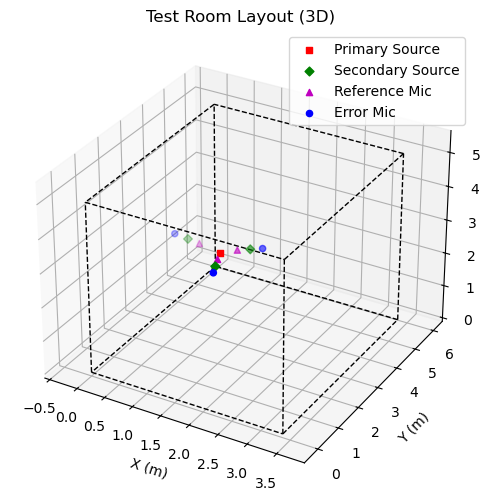

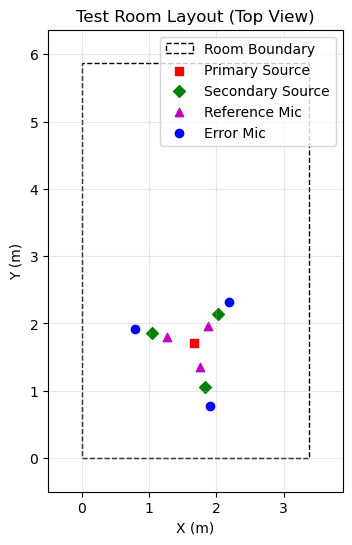

In [15]:
# 房间布局绘制（3D）——使用 RIRManager 自带绘图方法，效果学术与清晰
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
mgr.plot_layout(ax=ax)
plt.title('Test Room Layout (3D)')
plt.show()

# 2D 顶视图（更清晰的平面分布）
fig2, ax2 = plt.subplots(figsize=(7, 6))
mgr.plot_layout_2d(ax=ax2)
plt.title('Test Room Layout (Top View)')
plt.show()

---
### 说明与后续步骤
- 本 Notebook 使用与数据集构建一致的特征与几何采样方法，确保 `x_p` 与 `x_s` 的维度/统计分布与训练阶段对齐。
- 若需要在更多不同房间上做统计对比，可把上面的采样与仿真循环化（改变 `seed_new` 或多次调用 `sampler.sample()`），并收集 Mean NR / 收敛时间等指标。
- 若你的环境缺少 `pyroomacoustics`，请安装：`pip install pyroomacoustics`。

需要我现在在当前 `myenv` 环境中运行该 Notebook 的全部 cell 吗？（注意：仿真仅10s，耗时较短，但若进行大量重复实验请确保有足够时间）